In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import packages
import torch
from Index_Generators.IndexSequenceGenerator import IndexSequenceGenerator
import matplotlib.pyplot as plt

In [3]:
# Build an Index Sequence Generator
num_samples = 1000
h_size = 128
range_indices = 10
num_indices = 8
MyISG = IndexSequenceGenerator(LSTM_hidden_size=h_size, FFNN_hidden_size=h_size, num_categories=range_indices, FFNN_num_layers=3, sequence_size=num_indices, batch_size=num_samples)

In [5]:
# Run the index sequence generator
input_index = torch.randint(0, range_indices, (num_samples,1)).float()
h0 = torch.randn(num_samples, h_size)
c0 = torch.randn(num_samples, h_size)
indices, total_logP, total_entropy, _, _ = MyISG(h0, c0)

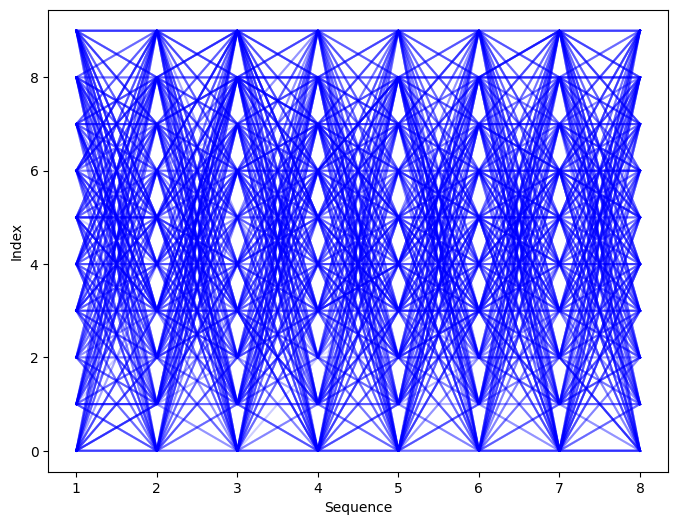

In [6]:
# Plot the results
x = torch.arange(1, num_indices+1).detach()
y = indices.detach()
# sizes = torch.exp(logProb.detach()) * 1000  
plt.figure(figsize=(8, 6))
for i in range(num_samples):
    plt.plot(x, y[i], color='blue', alpha=0.1)
plt.xlabel("Sequence")
plt.ylabel("Index")
plt.show()